<a href="https://colab.research.google.com/github/miloszp2223/ZadanieML/blob/master/Lista5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 5. POŁĄCZENIA RESIDUALNE I TRANSFER LEARNING

## 0.Cel listy

Celem tej listy zadań jest zapoznanie się z:

* gotowymi architekturami sieci neuronowych,
* ideą **połączeń residualnych (skip connections)**,
* oraz praktycznym wykorzystaniem **transfer learningu** w zadaniach z zakresu wizji komputerowej.

W poprzednich listach budowaliśmy sieci neuronowe „od zera”, projektując architekturę warstwa po warstwie. W praktyce jednak **bardzo rzadko trenuje się modele od podstaw**- zamiast tego korzysta się z gotowych, sprawdzonych architektur i wag wytrenowanych na dużych zbiorach danych, dotrenowując model pod konretne zadanie.



W tej liście:

* skupimy się na architekturach z rodziny **ResNet**,
* zobaczymy, czym są i po co stosuje się połączenia residualne,
* porównamy różne strategie treningu:

  * inferencję na modelu pretrenowanym,
  * trenowanie tylko ostatniej warstwy,
  * fine-tuning całego modelu,
  * trening od zera.



Do wykonania zadania rekomendowane jest użycie zbioru **CIFAR** z torchvision z powodu, że jest to trudniejszy zbiór i powinno być na nim lepiej widać, różne schematy uczenia, ale jeśli będzie występowal problem z zasobami obliczeniowymi można wykonać zadanie na zbiorze **FashionMNIST**




## 1.Połączenia residualne- teoria

### Problem zanikającego i wybuchającego gradientu

Podczas trenowania sieci neuronowej używamy algorytmu **propagacji wstecznej (backpropagation)**, w którym gradient funkcji straty jest przekazywany od wyjścia sieci do jej początkowych warstw.

Dla bardzo głębokich sieci pojawiają się dwa poważne problemy:

###  Zanikający gradient (vanishing gradient)

* gradient w kolejnych warstwach staje się coraz mniejszy,
* pierwsze warstwy uczą się bardzo wolno lub wcale,
* sieć nie wykorzystuje swojej głębokości.

###  Wybuchający gradient (exploding gradient)

* gradient w kolejnych warstwach gwałtownie rośnie,
* prowadzi to do niestabilnego treningu,
* wagi mogą przyjmować bardzo duże wartości (NaN).

Oba problemy są szczególnie widoczne w **głębokich sieciach** (dziesiątki lub setki warstw).



## Skąd bierze się ten problem? (intuicyczna matematyka)

Rozważmy bardzo uproszczony przypadek sieci składającej się z wielu warstw:

$$
h_l = f(W_l h_{l-1})
$$


Podczas propagacji wstecznej gradient względem wcześniejszych warstw zawiera **iloczyn pochodnych**:

$$
\frac{\partial L}{\partial h_0}
$$

$$
\frac{\partial L}{\partial h_L}
\cdot
\prod_{l=1}^{L}
\frac{\partial h_l}{\partial h_{l-1}}
$$

Jeśli:

* pochodne są **mniejsze od 1** - iloczyn dąży do zera → *zanik gradientu*
* pochodne są **większe od 1** - iloczyn rośnie wykładniczo → *wybuch gradientu*

Nawet przy użyciu funkcji aktywacji takich jak ReLU oraz technik typu Batch Normalization, problem **nie znika całkowicie** dla bardzo głębokich sieci.

#### Dodatkowe materiały:
- [Vanishing AND Exploding Gradient Problem Explained](https://www.youtube.com/watch?v=CzNFuL_5uig)
- [kod + wizaulizacje problemu](https://www.geeksforgeeks.org/deep-learning/vanishing-and-exploding-gradients-problems-in-deep-learning/)




### Intuicja stojąca za połączeniem residualnym

Zastanówmy się nad prostym przypadkiem.

Załóżmy, że idealna transformacja pomiędzy wejściem a wyjściem pewnej części sieci to:
$$
H(x) = x
$$

Czyli: **warstwy nic nie zmieniają**.

Dla klasycznej sieci neuronowej oznacza to, że musi ona nauczyć się funkcji identyczności, co w praktyce **nie jest trywialne** dla wielu warstw nieliniowych.



Zamiast uczyć się funkcji:
$$
H(x)
$$

możemy uczyć się **residuum**:
$$
F(x) = H(x) - x
$$

Jeśli najlepszym rozwiązaniem jest identyczność, to:
$$
F(x) = 0
$$

Uczenie się „zera” lub „małej poprawki” jest:

* łatwiejsze,
* stabilniejsze,
* szybsze dla optymalizacji gradientowej.



### Wzór matematyczny połączenia residualnego

Połączenie residualne definiujemy jako:

$$
y = F(x) + x
$$

gdzie:

* x - wejście do bloku,
* F(x) - klasyczna transformacja (np. Conv -> ReLU -> Conv),
* y - wyjście bloku residualnego.

### Co to zmienia?

* gradient może przepływać **bezpośrednio** przez składnik (+x),
* nawet jeśli F(x) jest trudne do nauczenia,
* sieć zawsze ma „bezpieczną ścieżkę” dla propagacji gradientu.


## Najważniejsze konsekwencje połączeń residualnych

* umożliwiają trenowanie **bardzo głębokich sieci**,
* zmniejszają problem degradacji jakości,
* stabilizują propagację gradientu,
* sprawiają, że dodawanie kolejnych warstw **nie pogarsza wyników**.

Poniżej obrazek przedstawiający schemat działania tego połączenia.


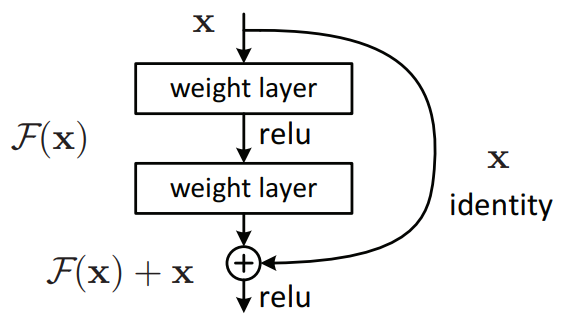

DODATKOWE MATERIAŁY:
- [ORGINALNY PAPER](https://arxiv.org/pdf/1512.03385) - Gorąco polecam, ponieważ autorzy bardzo klarownie postawili hipotezę, ekperyment weryfikujący, oraz wnioski. Jest to wzór pod względem tego jak publikacja powinna wyglądać.
- [ORGINALNY PAPER OMÓWIENIE NA YT](https://www.youtube.com/watch?v=GWt6Fu05voI)
- [SZCZEGÓŁOWE WYJAŚNIENIE](https://mbrenndoerfer.com/writing/residual-connections-deep-neural-networks-resnet)

## 2. ZADANIE 1. IMPLEMENTACJA MODUŁU RESIDUALNEGO
Jako zadanie rozgrzewkowe należy na podstawie schematu powyżej dokończyć implementację modułu residualnego, przepuścić przez niego "dummy input" i uruchomić testy w celu weryfikacji poprawności. Celem jest zobaczenie przykładowej implementacji takiego bloku.

**UWAGA**: Symbol "+" na schemacie odpowada zwykłemu **dodaniu tensorów** a nie konkatenacji.

In [ ]:
#Dummy wejście (NIE NALEŻY MODYFIKOWAĆ KOMÓRKI)

import torch
# Ustalmy powtarzalność
torch.manual_seed(0)

# Dummy batch obrazów: (batch_size, channels, height, width)
B, C, H, W = 4, 16, 32, 32
x = torch.randn(B, C, H, W)
print("x shape:", x.shape)


x shape: torch.Size([4, 16, 32, 32])


In [ ]:
# Moduł ResidualBlock z brakującym kodem (TODO)

import torch.nn as nn
import torch.nn.functional as F

class ResidualBlock(nn.Module):
    """
    Blok residualny zgodny ze schematem:
        x -> Conv -> ReLU -> Conv -> ( + x ) -> ReLU
    Zakładamy, że wejście i wyjście mają te same wymiary (C, H, W).
    """
    def __init__(self, channels: int, kernel_size: int = 3):
        super().__init__()
        padding = kernel_size // 2  # żeby zachować H,W dla kernel=3

        self.conv1 = nn.Conv2d(channels, channels, kernel_size=kernel_size, padding=padding, bias=True)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=kernel_size, padding=padding, bias=True)
        self.relu = nn.ReLU(inplace=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # TODO 1: policz F(x) = Conv -> ReLU -> Conv
        # TODO 2: dodaj skip connection: out = F(x) + x
        # TODO 3: zastosuj ReLU na końcu i zwróć wynik

        # ----- START TODO -----
        fx = self.conv1(x)
        fx = self.relu(fx)
        fx = self.conv2(fx)

        # skip connection
        out = fx + x


        out = self.relu(out)

        return out
        # ----- END TODO -----


In [ ]:
# Testy (NIE NALEŻY MODYFIKOWAĆ KOMÓRKI)

def zero_out_conv(conv: nn.Conv2d):
    with torch.no_grad():
        conv.weight.zero_()
        if conv.bias is not None:
            conv.bias.zero_()

# 1) Inicjalizacja i test wymiarów
block = ResidualBlock(channels=C)

y = block(x)
print("y shape:", y.shape)

assert y.shape == x.shape, f"Shape mismatch: got {y.shape}, expected {x.shape}"
print("Shape test passed")

# 2) Test semantyczny: jeśli ustawimy wagi obu conv na 0 -> F(x)=0
#    wtedy y = ReLU(x) (bo na końcu jest ReLU po dodaniu).
zero_out_conv(block.conv1)
zero_out_conv(block.conv2)

y2 = block(x)
expected = torch.relu(x)

max_diff = (y2 - expected).abs().max().item()
print("max |y2 - ReLU(x)| =", max_diff)

assert torch.allclose(y2, expected, atol=1e-6), "Residual behavior test failed"
print("Residual behavior test passed (F(x)=0 => y=ReLU(x))")

# 3) Test gradientu: sprawdzamy czy gradient przepływa do x
x_req = x.clone().detach().requires_grad_(True)
y3 = block(x_req)
loss = y3.sum()
loss.backward()

grad_norm = x_req.grad.norm().item()
print("x grad norm:", grad_norm)

assert grad_norm > 0, "Gradient flow test failed (grad_norm should be > 0)"
print("Gradient flow test passed")


y shape: torch.Size([4, 16, 32, 32])
Shape test passed
max |y2 - ReLU(x)| = 0.0
Residual behavior test passed (F(x)=0 => y=ReLU(x))
x grad norm: 180.78993225097656
Gradient flow test passed


## 3. PRETRENOWANE MODELE I TRANSFER LEARNING


#### Dlaczego nie zawsze trenujemy model od zera?

W zadaniach z zakresu wizji komputerowej obrazy- niezależnie od konkretnego problemu- mają **wspólną strukturę**.

W głębokich sieciach konwolucyjnych:

* **początkowe warstwy** uczą się bardzo ogólnych cech:

  * krawędzie,
  * narożniki,
  * proste tekstury,
* **środkowe warstwy** łączą je w bardziej złożone wzorce:

  * fragmenty obiektów,
  * charakterystyczne kształty,
* **końcowe warstwy** są najbardziej specyficzne dla zadania:

  * konkretne klasy,
  * decyzje klasyfikacyjne.

Oznacza to, że wiedza zdobyta przez model na jednym zadaniu (np. klasyfikacja milionów obrazów) może być **ponownie wykorzystana** w innym, podobnym zadaniu.

Dlatego w praktyce:

* **nie musimy uczyć modelu wszystkiego od zera**,
* możemy wykorzystać wcześniej wyuczone wagi,
* oszczędzamy czas, dane i zasoby obliczeniowe.


DODATKOWE MATERIAŁY:
- [Co "widzą" CNN-y w kolejnych warstwach](https://arxiv.org/pdf/1311.2901)


## Podstawowe pojęcia: pretraining i transfer learning

**Model pretrenowany (pretrained model)**

* jego wagi zostały wyuczone na dużym zbiorze danych,
* zwykle na **ogólnym zadaniu** (np. klasyfikacja obrazów w przypadku computer vision, chodź nie musi tak być),
* Często mówi się o takim modelu w naszym rozwiązaniu jako **Backbone**, ponieważ on odpowada za większość "wiedzy" w naszym modelu.

W przypadku wizji komputerowej bardzo często modele są pretrenowane na zbiorze ImageNet, który zawiera miliony obrazów i tysiące klas.

Przykład:
Resnet18 z biblioteki torchvision wraz z wagami z ImageNeta.



**Zamrażanie wag**
- Polega na tym że część lub całość modelu (wag) nie przekazuje gradientu dalej, co oznacza że te konretne wagi nie będą się dalej optymalizowały w trakcie trenigu
- W torchu odbywa się między innymi poprzez
  * `requires_grad = False`,
- Stosowane kiedy chcemy pozostawić wagi modelu i zmodyfikować tylko jego fragment (najczęściej ostatnią warstwę klasyfikujacą lub pare ostatnich warst)


**Transfer learning**
Polega na wykorzystaniu modelu pretrenowanego oraz dostosowaniu go do **zadania docelowego**.

Może to przyjmować różne formy, w zależności od ilości danych i podobieństwa zadań. Jest to szeroki temat, ale najkrócej tłumacząc strategie jakie są nabardziej znane to:
- **linear probing**- Zamrożenie całości modelu i wytrenowaniu jedynie ostatniej warstwy klasyfikującej pod nasze zadanie .
- **partial fine-tuning**Zamrożenie większości modelu, ale dotrenowujemy też ostatnie warstwy/blocki w naszym backbonie . Ile dokładnie odmrażamy a ile zostawiamy jest bardzo mocno zależne od naszego zadania, ilości danych  oraz doświadczenia.
- **Full fine-tuning** Odmrożenie całego modelu i dotrenowanie go w całości naszych danych


DODATKOWE MATERIAŁY:
- [linear probing vs finetuning](https://www.phontron.com/class/anlp2022/assets/slides/anlp-10-raghunathan.pdf)
- [how to freez model in torch](https://python.plainenglish.io/how-to-freeze-model-weights-in-pytorch-for-transfer-learning-step-by-step-tutorial-a533a58051ef)



## Architektura ResNet i modele dostępne w torchvision

**ResNet (Residual Network)** to rodzina głębokich sieci konwolucyjnych opartych na:

* blokach residualnych,
* połączeniach typu skip connection,
* bardzo dużej głębokości (dziesiątki lub setki warstw).

Kluczowa idea:

* sieć uczy się **residuum** zamiast pełnej transformacji,
* co umożliwia stabilny trening bardzo głębokich modeli.


Biblioteka `torchvision.models` udostępnia gotowe implementacje ResNetów, m.in.:

* `resnet18`
* `resnet34`
* `resnet50`
* `resnet101`
* `resnet152`

Różnią się one:

* liczbą warstw,
* liczbą parametrów,
* złożonością bloków residualnych.

Modele te:

* mogą być inicjalizowane losowo,
* lub z wagami **pretrenowanymi na ImageNet**.


DODATKOWE MATERIAŁY:
- [torchvision resnet18](https://docs.pytorch.org/vision/main/models/generated/torchvision.models.resnet18.html)

## 4. ZADANIE 2- transfer learning



Celem zadania jest praktyczne zapoznanie się z różnymi strategiami wykorzystania **modeli pretrenowanych** na przykładzie architektury **ResNet** oraz porównanie ich zachowania podczas treningu.


### 1. Wybór i analiza architektury

1. Wybierz **jeden model z rodziny ResNet**:

   * `ResNet18` lub `ResNet34`
     (większe modele nie są wymagane do tego zadania).

2. Załaduj model **z wagami pretrenowanymi na ImageNet**.

3. Wyświetl architekturę modelu (`print(model)` lub podobnie) i:

   * zidentyfikuj część konwolucyjną (backbone),
   * zlokalizuj ostatnią warstwę klasyfikacyjną,
   * zwróć uwagę na strukturę bloków residualnych.

Celem tego punktu jest **zrozumienie, z jakich elementów składa się model**, a nie tylko jego użycie jako „czarnej skrzynki”.


### 2. Przygotowanie danych i wyjścia modelu

1. Wykorzystaj zbiór danych wskazany we wprowadzeniu (np. CIFAR / FashionMNIST).
2. Dostosuj dane wejściowe do wymagań modelu:

   * odpowiedni rozmiar obrazu,
   * liczba kanałów,
   * normalizacja.

3. Zastąp **ostatnią warstwę liniową** modelu tak, aby liczba neuronów wyjściowych odpowiadała liczbie klas w zadaniu docelowym.


### 3. Zestaw eksperymentów

Na tym samym zbiorze danych przeprowadź **następujące eksperymenty**, zachowując spójne ustawienia (batch size, optimizer, itp.).

- Eksperyment 1 - Linear probing

  * Zamroź wszystkie warstwy modelu poza ostatnią warstwą liniową.
  * Trenuj **tylko nową warstwę klasyfikacyjną**.
  * Model pełni rolę ekstraktora cech.


- Eksperyment 2 - Partial fine-tuning

  * Zamroź większość modelu,
  * Odmroź:

    * ostatni blok ResNeta,
    * oraz warstwę klasyfikacyjną.
  * Trenuj tylko te elementy.


- Eksperyment 3 - Full fine-tuning

  * Użyj modelu pretrenowanego,
  * Odmroź **wszystkie warstwy**,
  * Dotrenuj cały model na zadaniu docelowym.
  * Trening **nie musi być długi** - wystarczy kilka lub kilkanaście epok.


- Eksperyment 4 - Trening od zera

  * Załaduj ten sam model ResNet, ale **bez wag pretrenowanych**.
  * Wytrenuj go od zera na tym samym zbiorze danych.
  * Wystarczy kilka pierwszych epok - celem jest obserwacja przebiegu uczenia.


### UWAGI

* Stosuj dobre praktyki treningowe z poprzednich list.
* **Zawsze śledź `train loss` oraz `validation loss`** - w tym zadaniu jest to szczególnie istotne.
* Monitoruj metryki na zbiorze treningowym, walidacyjnym i testowym.
* Porównuj podejścia między sobą:

  * wartości strat,
  * metryki walidacyjne i testowe,
  * szybkość oraz stabilność zbieżności.
* Zwróć uwagę na różnice w przebiegu krzywych uczenia między ekperymentami.
* Przy full fine-tuningu i treningu od zera **wystarczy kilka / kilkanaście epok** - nie jest wymagane doprowadzenie treningu do pełnej konwergencji.
* Celem zadania jest **zrozumienie dynamiki uczenia i wpływu pretrenowania**, a nie maksymalizacja końcowej dokładności.
* Przy dotrenowywaniu, często stosuje się mniejszy lr niż przy treningu od zera.


Trainer i funkcje do pokazania metryk zaimportowane z poprzednich list:

In [ ]:
import torch
import torchvision.models as models
import inspect
from torch.utils.data import random_split
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import copy
import random
from torch import optim


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed = 8
set_seed(seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
def train_model(
    model,
    train_loader,
    val_loader=None,
    epochs=15,
    lr=0.0005,
    patience=5,
    optim_class=optim.Adam,
    device="cuda" if torch.cuda.is_available() else "cpu",
    l2_lambda=0.0,
    use_cosine_scheduler=True
):

    model.to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim_class(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=l2_lambda if l2_lambda > 0 else 0.0
    )

    scheduler = None
    if use_cosine_scheduler:
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=epochs,
            eta_min=1e-6
        )


    best_val_loss = float("inf")
    epochs_no_improve = 0
    best_model_wts = copy.deepcopy(model.state_dict())

    history = {
        "train_loss": [],
        "train_acc": [],
        "train_precision": [],
        "train_recall": [],
        "train_f1": [],
        "val_loss": [],
        "val_acc": [],
        "val_precision": [],
        "val_recall": [],
        "val_f1": [],
        "lr": []
    }

    for epoch in range(epochs):
        #print("epoch start")
        # ===== TRAIN =====
        model.train()
        train_loss = 0.0
        all_preds, all_targets = [], []

        for x, y in train_loader:

            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            outputs = model(x)

            loss = criterion(outputs, y)

            loss.backward()
            optimizer.step()

            train_loss += loss.item() * x.size(0)
            _, preds = torch.max(outputs, 1)

            all_preds.append(preds.cpu())
            all_targets.append(y.cpu())

        all_preds = torch.cat(all_preds).numpy()
        all_targets = torch.cat(all_targets).numpy()

        train_loss /= len(train_loader.dataset)
        train_acc = accuracy_score(all_targets, all_preds)
        train_precision = precision_score(all_targets, all_preds, average="macro", zero_division=0)
        train_recall = recall_score(all_targets, all_preds, average="macro", zero_division=0)
        train_f1 = f1_score(all_targets, all_preds, average="macro", zero_division=0)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["train_precision"].append(train_precision)
        history["train_recall"].append(train_recall)
        history["train_f1"].append(train_f1)

        # ===== VALIDATION =====
        if val_loader is not None:
            model.eval()
            val_loss = 0.0
            all_preds, all_targets = [], []

            with torch.no_grad():
                for x, y in val_loader:
                    x, y = x.to(device), y.to(device)
                    outputs = model(x)
                    loss = criterion(outputs, y)

                    val_loss += loss.item() * x.size(0)
                    _, preds = torch.max(outputs, 1)

                    all_preds.append(preds.cpu())
                    all_targets.append(y.cpu())

            all_preds = torch.cat(all_preds).numpy()
            all_targets = torch.cat(all_targets).numpy()

            val_loss /= len(val_loader.dataset)
            val_acc = accuracy_score(all_targets, all_preds)
            val_precision = precision_score(all_targets, all_preds, average="macro", zero_division=0)
            val_recall = recall_score(all_targets, all_preds, average="macro", zero_division=0)
            val_f1 = f1_score(all_targets, all_preds, average="macro", zero_division=0)

            history["val_loss"].append(val_loss)
            history["val_acc"].append(val_acc)
            history["val_precision"].append(val_precision)
            history["val_recall"].append(val_recall)
            history["val_f1"].append(val_f1)

        current_lr = optimizer.param_groups[0]["lr"]
        history["lr"].append(current_lr)

        if val_loader is not None:
            print(
                f"Epoch [{epoch+1}/{epochs}] | "
                f"LR:{current_lr:.6f} | "
                f"Train L:{train_loss:.4f} A:{train_acc:.4f} "
                f"F1:{train_f1:.4f} | "
                f"Val L:{val_loss:.4f} A:{val_acc:.4f} "
                f"F1:{val_f1:.4f}"
            )

            if patience > 0:
                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    best_model_wts = copy.deepcopy(model.state_dict())
                    epochs_no_improve = 0
                else:
                    epochs_no_improve += 1
                    if epochs_no_improve >= patience:
                        print("Early stopping")
                        model.load_state_dict(best_model_wts)
                        return model, history
        if scheduler is not None:
          scheduler.step()

    model.load_state_dict(best_model_wts)
    return model, history

#=========================================

In [ ]:
def plot_history(history, title):
    epochs = range(1, len(history["lr"]) + 1)

    plt.figure(figsize=(20, 4))

    # ===== LR =====
    plt.subplot(1, 4, 1)
    plt.plot(epochs, history["lr"])
    plt.title("Learning Rate")
    plt.xlabel("Epoch")
    plt.ylabel("LR")

    # ===== LOSS =====
    plt.subplot(1, 4, 2)
    plt.plot(epochs, history["train_loss"], label="Train")
    if len(history["val_loss"]) > 0:
        plt.plot(epochs, history["val_loss"], label="Val")
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.legend()

    # ===== ACCURACY =====
    plt.subplot(1, 4, 3)
    plt.plot(epochs, history["train_acc"], label="Train")
    if len(history["val_acc"]) > 0:
        plt.plot(epochs, history["val_acc"], label="Val")
    plt.title("Accuracy")
    plt.xlabel("Epoch")
    plt.legend()

    # ===== F1 =====
    plt.subplot(1, 4, 4)
    plt.plot(epochs, history["train_f1"], label="Train")
    if len(history["val_f1"]) > 0:
        plt.plot(epochs, history["val_f1"], label="Val")
    plt.title("F1 Score")
    plt.xlabel("Epoch")
    plt.legend()

    plt.suptitle(title, fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [ ]:
def evaluate_model(
    model,
    test_loader,
    device="cuda" if torch.cuda.is_available() else "cpu"
):
    model.to(device)
    model.eval()

    criterion = nn.CrossEntropyLoss()

    test_loss = 0.0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)

            outputs = model(x)
            loss = criterion(outputs, y)

            test_loss += loss.item() * x.size(0)
            _, preds = torch.max(outputs, 1)

            all_preds.append(preds.cpu())
            all_targets.append(y.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()

    test_loss /= len(test_loader.dataset)
    test_acc = accuracy_score(all_targets, all_preds)
    test_precision = precision_score(all_targets, all_preds, average="macro", zero_division=0)
    test_recall = recall_score(all_targets, all_preds, average="macro", zero_division=0)
    test_f1 = f1_score(all_targets, all_preds, average="macro", zero_division=0)

    print("\n===== TEST RESULTS =====")
    print(f"Test Loss:      {test_loss:.4f}")
    print(f"Test Accuracy:  {test_acc:.4f}")
    print(f"Test Precision: {test_precision:.4f}")
    print(f"Test Recall:    {test_recall:.4f}")
    print(f"Test F1-score:  {test_f1:.4f}")

    return {
        "test_loss": test_loss,
        "test_acc": test_acc,
        "test_precision": test_precision,
        "test_recall": test_recall,
        "test_f1": test_f1
    }


#evaluate_model(model, test_loader)

Analiza struktury modelu

In [ ]:

model = models.resnet18(weights='DEFAULT')

print("==================Cały model:")
print(model)
print("==================Warstwa klasyfikacyjna (tutaj jedyna liniowa):")
print(model.fc)
print("==================Struktura bloku:")
print(inspect.getsource(model.layer1[0].__class__))


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 39.7MB/s]


==================Cały model:
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     

Analiza danych wejściowych i przystosowanie ich do modelu

In [ ]:
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])#transformacja z dokumentacji resnet18


full_train = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)
testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_size = int(0.8 * len(full_train))   # 80%
val_size = len(full_train) - train_size   # 20%

trainset, valset = random_split(full_train, [train_size, val_size])

trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
valloader = torch.utils.data.DataLoader(valset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
"""
img, label = trainset[0]
print("Shape:", img.shape)
plt.imshow(np.transpose(img, (1, 2, 0)))
plt.show()
print(full_train.classes[label])
print(len(full_train.classes))
print(full_train.classes)
"""


100%|██████████| 170M/170M [00:03<00:00, 47.2MB/s]


'\nimg, label = trainset[0]\nprint("Shape:", img.shape)\nplt.imshow(np.transpose(img, (1, 2, 0)))\nplt.show()\nprint(full_train.classes[label])\nprint(len(full_train.classes))\nprint(full_train.classes)\n'

In [ ]:
def newModel(pretrained = True):
    set_seed(8)
    if pretrained:
        model = models.resnet18(weights='DEFAULT')
    else:
        model = models.resnet18()
    num_classes = 10
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


Eksperyment 1

Epoch [1/15] | LR:0.000500 | Train L:1.0231 A:0.6891 F1:0.6884 | Val L:0.7020 A:0.7730 F1:0.7720
Epoch [2/15] | LR:0.000495 | Train L:0.6746 A:0.7766 F1:0.7764 | Val L:0.6276 A:0.7881 F1:0.7877
Epoch [3/15] | LR:0.000478 | Train L:0.6233 A:0.7903 F1:0.7902 | Val L:0.6007 A:0.7929 F1:0.7932
Epoch [4/15] | LR:0.000452 | Train L:0.5993 A:0.7947 F1:0.7946 | Val L:0.5863 A:0.7969 F1:0.7953
Epoch [5/15] | LR:0.000417 | Train L:0.5827 A:0.7997 F1:0.7997 | Val L:0.5706 A:0.8022 F1:0.8024
Epoch [6/15] | LR:0.000375 | Train L:0.5711 A:0.8047 F1:0.8046 | Val L:0.5692 A:0.8040 F1:0.8037
Epoch [7/15] | LR:0.000328 | Train L:0.5632 A:0.8063 F1:0.8062 | Val L:0.5666 A:0.8051 F1:0.8045
Epoch [8/15] | LR:0.000277 | Train L:0.5550 A:0.8095 F1:0.8094 | Val L:0.5646 A:0.8051 F1:0.8043
Epoch [9/15] | LR:0.000224 | Train L:0.5529 A:0.8113 F1:0.8112 | Val L:0.5620 A:0.8042 F1:0.8044
Epoch [10/15] | LR:0.000173 | Train L:0.5500 A:0.8106 F1:0.8105 | Val L:0.5614 A:0.8092 F1:0.8080
Epoch [11/15] | LR:0.000126 |

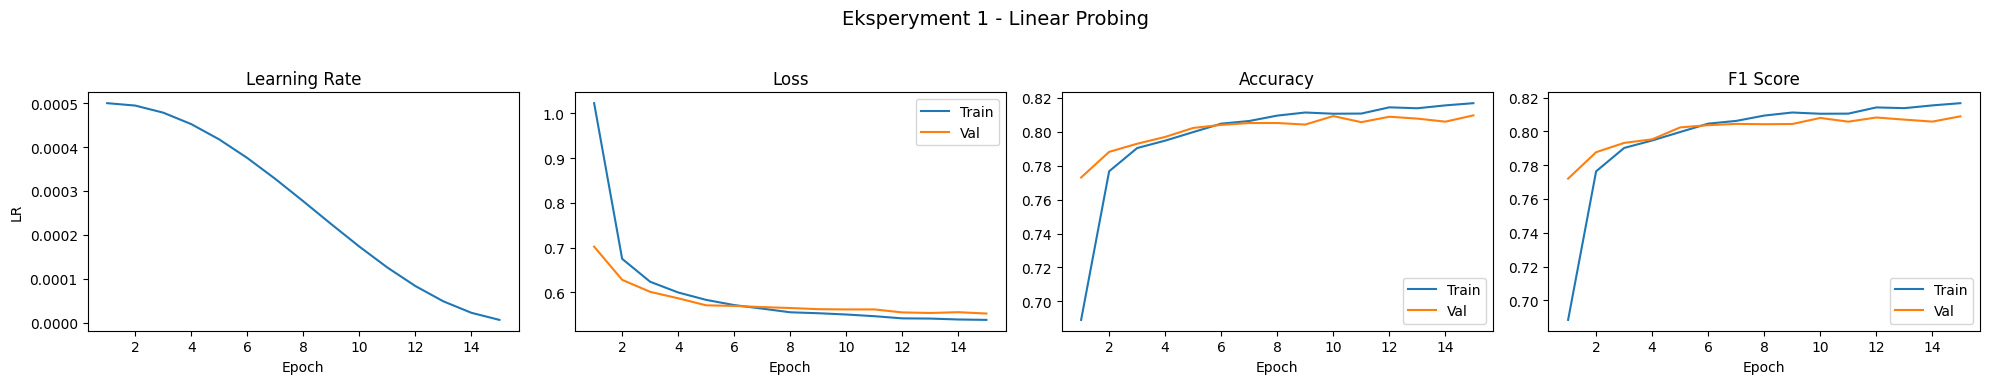

-----ewaluacja modelu:

===== TEST RESULTS =====
Test Loss:      0.5636
Test Accuracy:  0.8081
Test Precision: 0.8077
Test Recall:    0.8081
Test F1-score:  0.8077


{'test_loss': 0.5635736758232117,
 'test_acc': 0.8081,
 'test_precision': 0.8077397031297855,
 'test_recall': 0.8080999999999999,
 'test_f1': 0.8077350460495054}

In [ ]:
model = newModel(True)

# Zamrożenie wag
for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True


text = "Eksperyment 1 - Linear Probing"
m, hst =train_model(model=model, train_loader=trainloader, val_loader=valloader)
plot_history(hst, text)
print("-----ewaluacja modelu:")
evaluate_model(model=m, test_loader=testloader)

Tutaj na samym początku zdecydowanie poprawiła się wydajność modelu i później poprawiała się stopniowo, bez overfittingu.

Eksperyment 2

Epoch [1/15] | LR:0.000500 | Train L:0.4296 A:0.8520 F1:0.8519 | Val L:0.3344 A:0.8827 F1:0.8822
Epoch [2/15] | LR:0.000495 | Train L:0.1723 A:0.9405 F1:0.9404 | Val L:0.3133 A:0.8966 F1:0.8966
Epoch [3/15] | LR:0.000478 | Train L:0.0801 A:0.9724 F1:0.9724 | Val L:0.3295 A:0.9024 F1:0.9019
Epoch [4/15] | LR:0.000452 | Train L:0.0482 A:0.9841 F1:0.9841 | Val L:0.3832 A:0.8936 F1:0.8928
Epoch [5/15] | LR:0.000417 | Train L:0.0325 A:0.9896 F1:0.9896 | Val L:0.3385 A:0.9096 F1:0.9095
Epoch [6/15] | LR:0.000375 | Train L:0.0227 A:0.9927 F1:0.9927 | Val L:0.3703 A:0.9047 F1:0.9047
Epoch [7/15] | LR:0.000328 | Train L:0.0131 A:0.9958 F1:0.9958 | Val L:0.3984 A:0.9062 F1:0.9066
Early stopping


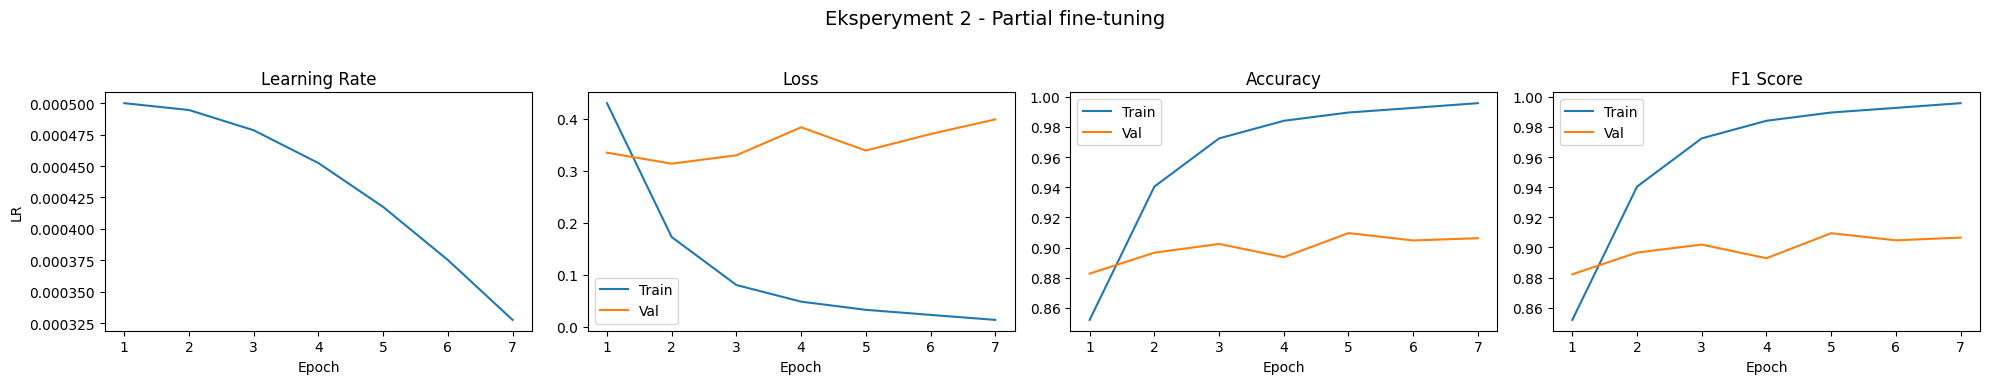

-----ewaluacja modelu:

===== TEST RESULTS =====
Test Loss:      0.3223
Test Accuracy:  0.8965
Test Precision: 0.8980
Test Recall:    0.8965
Test F1-score:  0.8967


{'test_loss': 0.32231008644104003,
 'test_acc': 0.8965,
 'test_precision': 0.8979646860301221,
 'test_recall': 0.8965,
 'test_f1': 0.8966733963727094}

In [ ]:
model = newModel(True)

# Zamrożenie wag
for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True
for param in model.layer4.parameters():
    param.requires_grad = True

text = "Eksperyment 2 - Partial fine-tuning"
m, hst =train_model(model=model, train_loader=trainloader, val_loader=valloader)
plot_history(hst, text)
print("-----ewaluacja modelu:")
evaluate_model(model=m, test_loader=testloader)

Tutaj w miarę szybko zaszedł overfitting, ale model osiągnął zdecydowanie lepszy wynik niż po linear probingu.

Eksperyment 3

Epoch [1/15] | LR:0.000500 | Train L:0.4491 A:0.8468 F1:0.8467 | Val L:0.3653 A:0.8777 F1:0.8778
Epoch [2/15] | LR:0.000495 | Train L:0.2355 A:0.9199 F1:0.9198 | Val L:0.3208 A:0.8881 F1:0.8885
Epoch [3/15] | LR:0.000478 | Train L:0.1465 A:0.9505 F1:0.9505 | Val L:0.3291 A:0.8939 F1:0.8941
Epoch [4/15] | LR:0.000452 | Train L:0.0933 A:0.9679 F1:0.9679 | Val L:0.2993 A:0.9044 F1:0.9047
Epoch [5/15] | LR:0.000417 | Train L:0.0634 A:0.9794 F1:0.9794 | Val L:0.2646 A:0.9158 F1:0.9154
Epoch [6/15] | LR:0.000375 | Train L:0.0433 A:0.9853 F1:0.9853 | Val L:0.2859 A:0.9152 F1:0.9142
Epoch [7/15] | LR:0.000328 | Train L:0.0234 A:0.9925 F1:0.9925 | Val L:0.2830 A:0.9276 F1:0.9276
Epoch [8/15] | LR:0.000277 | Train L:0.0201 A:0.9933 F1:0.9933 | Val L:0.2803 A:0.9260 F1:0.9261
Epoch [9/15] | LR:0.000224 | Train L:0.0104 A:0.9969 F1:0.9968 | Val L:0.2459 A:0.9354 F1:0.9353
Epoch [10/15] | LR:0.000173 | Train L:0.0036 A:0.9991 F1:0.9991 | Val L:0.2167 A:0.9430 F1:0.9428
Epoch [11/15] | LR:0.000126 |

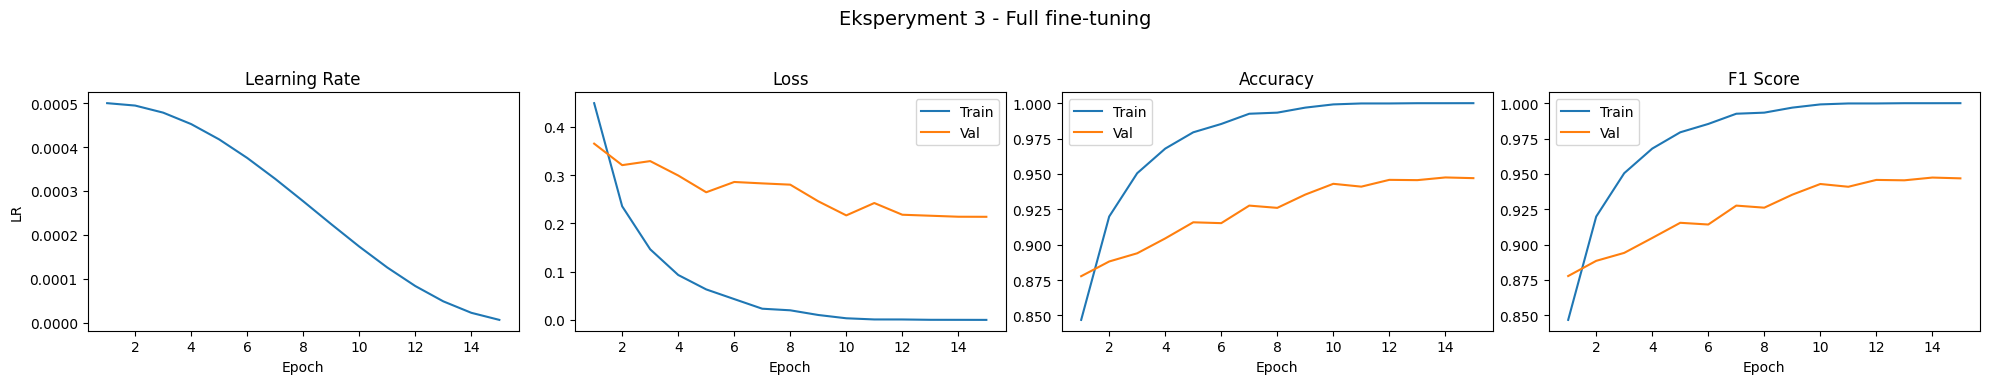

-----ewaluacja modelu:

===== TEST RESULTS =====
Test Loss:      0.2267
Test Accuracy:  0.9455
Test Precision: 0.9454
Test Recall:    0.9455
Test F1-score:  0.9454


{'test_loss': 0.22671705343127252,
 'test_acc': 0.9455,
 'test_precision': 0.9454087557483648,
 'test_recall': 0.9455,
 'test_f1': 0.9453588532471379}

In [ ]:
model = newModel(True)

for param in model.parameters():
    param.requires_grad = True

text = "Eksperyment 3 - Full fine-tuning"
m, hst =train_model(model=model, train_loader=trainloader, val_loader=valloader)
plot_history(hst, text)
print("-----ewaluacja modelu:")
evaluate_model(model=m, test_loader=testloader)

Po odmrożeniu całego modelu metryki trochę się poprawiły i w tym przypadku były najlepsze ze wszystkich eksperymentów. Ogólnie w miarę podobne wyniki do Eksperymentu 2, ale tutaj na początku trochę wolniej zachodziła poprawa metryk.

Eksperyment 4

Epoch [1/15] | LR:0.000500 | Train L:1.3248 A:0.5162 F1:0.5128 | Val L:1.1160 A:0.6017 F1:0.5980
Epoch [2/15] | LR:0.000495 | Train L:0.8404 A:0.7036 F1:0.7025 | Val L:0.9401 A:0.6693 F1:0.6757
Epoch [3/15] | LR:0.000478 | Train L:0.6265 A:0.7797 F1:0.7791 | Val L:0.7492 A:0.7462 F1:0.7491
Epoch [4/15] | LR:0.000452 | Train L:0.4976 A:0.8282 F1:0.8277 | Val L:0.7798 A:0.7494 F1:0.7425
Epoch [5/15] | LR:0.000417 | Train L:0.3763 A:0.8706 F1:0.8702 | Val L:0.6160 A:0.7933 F1:0.7950
Epoch [6/15] | LR:0.000375 | Train L:0.2736 A:0.9058 F1:0.9056 | Val L:0.5539 A:0.8226 F1:0.8215
Epoch [7/15] | LR:0.000328 | Train L:0.1726 A:0.9410 F1:0.9409 | Val L:0.6480 A:0.8073 F1:0.8094
Epoch [8/15] | LR:0.000277 | Train L:0.0881 A:0.9722 F1:0.9721 | Val L:0.6295 A:0.8217 F1:0.8205
Epoch [9/15] | LR:0.000224 | Train L:0.0404 A:0.9889 F1:0.9889 | Val L:0.6278 A:0.8331 F1:0.8364
Epoch [10/15] | LR:0.000173 | Train L:0.0159 A:0.9968 F1:0.9968 | Val L:0.5882 A:0.8487 F1:0.8496
Epoch [11/15] | LR:0.000126 |

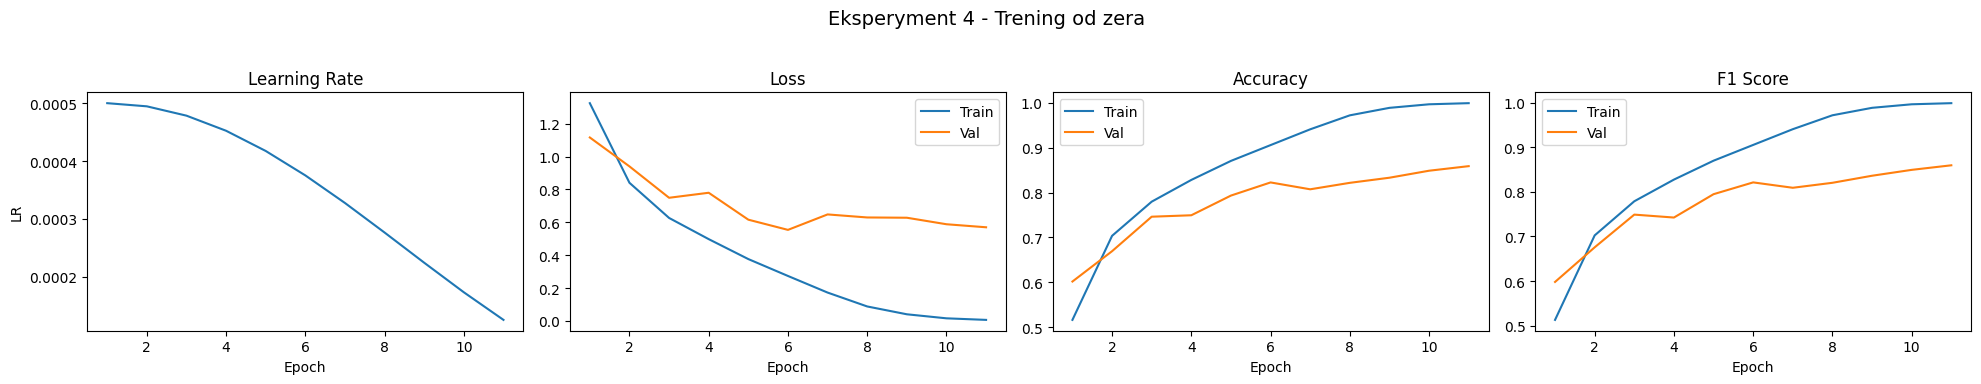

-----ewaluacja modelu:

===== TEST RESULTS =====
Test Loss:      0.5545
Test Accuracy:  0.8255
Test Precision: 0.8294
Test Recall:    0.8255
Test F1-score:  0.8231


{'test_loss': 0.5545051773071289,
 'test_acc': 0.8255,
 'test_precision': 0.8293622483726104,
 'test_recall': 0.8255000000000001,
 'test_f1': 0.8230824260177168}

In [ ]:
model = newModel(False)

for param in model.parameters():
    param.requires_grad = True

text = "Eksperyment 4 - Trening od zera"
m, hst =train_model(model=model, train_loader=trainloader, val_loader=valloader)
plot_history(hst, text)
print("-----ewaluacja modelu:")
evaluate_model(model=m, test_loader=testloader)

W modelu bez pretrenowanych wag też praktycznie szybko nastąpił overfitting i końcowe metryki wypadły gorzej niż w przypadkach 2 i 3.
